In [1]:
import os
import zipfile
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import zipfile, os

outer_zip = "/content/All_Cohorts.zip"
extract_dir = "/content/All_Cohorts_RelAbundance"

# Extract outer zip
with zipfile.ZipFile(outer_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Extracted outer zip to:", extract_dir)
print("Inner cohort zips:", os.listdir(extract_dir))


Extracted outer zip to: /content/All_Cohorts_RelAbundance
Inner cohort zips: ['BIO_ML_2019.zip', 'IBD_2019.zip', 'CRC_2019.zip', 'INFANTS_MFGM_2019.zip', 'AUTISM_2017.zip', 'PRETERMS_2018.zip', 'ADENOMAS_2020.zip', 'CRC_2016.zip', 'ESRD_2020.zip', 'IBS_2020.zip', 'IBDMDB_2019.zip', 'IBD_FAMILIES_2016.zip', 'INFANTS_DIABETES_2015.zip', 'RAWIJANTARI_GASTRIC_CANCER.zip']


In [3]:
cohort_dir = extract_dir
inner_cohorts = [f for f in os.listdir(cohort_dir) if f.endswith(".zip")]

all_data = []

for cohort_zip in inner_cohorts:
    cohort_name = cohort_zip.replace(".zip", "")
    cohort_path = os.path.join(cohort_dir, cohort_zip)
    extract_path = os.path.join(cohort_dir, cohort_name)

    # Extract inner cohort zip
    with zipfile.ZipFile(cohort_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    # Find CSV inside
    csv_files = [f for f in os.listdir(extract_path) if f.endswith(".csv")]
    if not csv_files:
        print(f"⚠️ No CSV found in {cohort_name}")
        continue

    cohort_csv = os.path.join(extract_path, csv_files[0])
    print(f"Reading {cohort_csv}")

    import pandas as pd
    df = pd.read_csv(cohort_csv)
    df["Cohort"] = cohort_name
    all_data.append(df)


Reading /content/All_Cohorts_RelAbundance/BIO_ML_2019/BIO_ML_2019_metadata.csv
Reading /content/All_Cohorts_RelAbundance/IBD_2019/IBD_2019_metabolites.csv
Reading /content/All_Cohorts_RelAbundance/CRC_2019/CRC_2019_metabolites.csv
Reading /content/All_Cohorts_RelAbundance/INFANTS_MFGM_2019/INFANTS_MFGM_2019_metadata.csv
Reading /content/All_Cohorts_RelAbundance/AUTISM_2017/AUTISM_2017_metabolites.csv
Reading /content/All_Cohorts_RelAbundance/PRETERMS_2018/PRETERMS_2018_metadata.csv
Reading /content/All_Cohorts_RelAbundance/ADENOMAS_2020/ADENOMAS_2020_metadata.csv
Reading /content/All_Cohorts_RelAbundance/CRC_2016/CRC_2016_metadata.csv
Reading /content/All_Cohorts_RelAbundance/ESRD_2020/ESRD_2020_metabolites.csv
Reading /content/All_Cohorts_RelAbundance/IBS_2020/IBS_2020_metadata.csv
Reading /content/All_Cohorts_RelAbundance/IBDMDB_2019/IBDMDB_2019_metabolites.csv
Reading /content/All_Cohorts_RelAbundance/IBD_FAMILIES_2016/IBD_FAMILIES_2016_metabolites.csv
Reading /content/All_Cohorts_R

In [4]:
import pandas as pd

all_data = []  # store merged dfs for all cohorts

cohort_zips = [os.path.join(extract_dir, f) for f in os.listdir(extract_dir) if f.endswith(".zip")]

for cohort_zip in cohort_zips:
    cohort_name = os.path.basename(cohort_zip).replace(".zip", "")
    print(f"\nProcessing cohort: {cohort_name}")

    # Temporary extract
    temp_dir = os.path.join(extract_dir, cohort_name)
    os.makedirs(temp_dir, exist_ok=True)

    with zipfile.ZipFile(cohort_zip, 'r') as zip_ref:
        zip_ref.extractall(temp_dir)
        files = zip_ref.namelist()
        print(" Files inside:", files)

    # Expected files
    meta_file = [f for f in files if "metadata" in f.lower()][0]
    micro_file = [f for f in files if "microbiome" in f.lower()][0]
    metab_file = [f for f in files if "metabolites" in f.lower()][0]

    # Load
    meta_df = pd.read_csv(os.path.join(temp_dir, meta_file))
    micro_df = pd.read_csv(os.path.join(temp_dir, micro_file))
    metab_df = pd.read_csv(os.path.join(temp_dir, metab_file))

    # Merge on SampleID
    merged = meta_df.merge(micro_df, on="SampleID").merge(metab_df, on="SampleID")

    # Add cohort label
    merged["Cohort"] = cohort_name

    print(f" {cohort_name} shape after merge:", merged.shape)

    all_data.append(merged)



Processing cohort: BIO_ML_2019
 Files inside: ['BIO_ML_2019_metadata.csv', 'BIO_ML_2019_microbiome.csv', 'BIO_ML_2019_metabolites.csv']
 BIO_ML_2019 shape after merge: (500, 54)

Processing cohort: IBD_2019
 Files inside: ['IBD_2019_metadata.csv', 'IBD_2019_microbiome.csv', 'IBD_2019_metabolites.csv']
 IBD_2019 shape after merge: (500, 54)

Processing cohort: CRC_2019
 Files inside: ['CRC_2019_metadata.csv', 'CRC_2019_microbiome.csv', 'CRC_2019_metabolites.csv']
 CRC_2019 shape after merge: (500, 54)

Processing cohort: INFANTS_MFGM_2019
 Files inside: ['INFANTS_MFGM_2019_metadata.csv', 'INFANTS_MFGM_2019_microbiome.csv', 'INFANTS_MFGM_2019_metabolites.csv']
 INFANTS_MFGM_2019 shape after merge: (500, 54)

Processing cohort: AUTISM_2017
 Files inside: ['AUTISM_2017_metadata.csv', 'AUTISM_2017_microbiome.csv', 'AUTISM_2017_metabolites.csv']
 AUTISM_2017 shape after merge: (500, 54)

Processing cohort: PRETERMS_2018
 Files inside: ['PRETERMS_2018_metadata.csv', 'PRETERMS_2018_microbiome

In [ ]:
# Combine all cohorts
df = pd.concat(all_data, ignore_index=True)
print("\n✅ Final merged dataset shape:", df.shape)

# Save for modeling
df.to_csv("/content/All_Cohorts_Merged.csv", index=False)
print("Saved merged dataset to /content/All_Cohorts_Merged.csv")



✅ Final merged dataset shape: (7000, 54)
Saved merged dataset to /content/All_Cohorts_Merged.csv


In [ ]:
# Assume df is your merged dataset
# Keep SampleID separate if exists
metadata_cols = ['Age', 'BMI', 'BloodPressure', 'CholesterolLevel',
                 'Gender', 'Group', 'HealthStatus', 'SmokingStatus',
                 'AlcoholConsumption', 'Diabetes', 'StudyGroup']

numeric_cols = ['Age', 'BMI', 'BloodPressure', 'CholesterolLevel']
categorical_cols = [col for col in metadata_cols if col not in numeric_cols]


In [ ]:
from sklearn.impute import SimpleImputer

X = df.copy()

# numeric and categorical columns
numeric_cols = ['Age', 'BMI', 'BloodPressure', 'CholesterolLevel']
categorical_cols = ['Gender', 'Group', 'HealthStatus', 'SmokingStatus',
                    'AlcoholConsumption', 'Diabetes', 'StudyGroup']

# 1️⃣ Drop categorical columns that are completely NaN
cat_valid = [c for c in categorical_cols if X[c].notna().sum() > 0]
print("Using categorical columns:", cat_valid)

# 2️⃣ Impute numeric columns (median)
num_imputer = SimpleImputer(strategy='median')
X[numeric_cols] = num_imputer.fit_transform(X[numeric_cols])

# 3️⃣ Impute categorical columns (most frequent)
cat_imputer = SimpleImputer(strategy='most_frequent')
X[cat_valid] = cat_imputer.fit_transform(X[cat_valid])

print("✅ Imputation done! Missing values handled successfully.")


Using categorical columns: ['Gender', 'Group', 'HealthStatus', 'SmokingStatus', 'AlcoholConsumption', 'Diabetes']
✅ Imputation done! Missing values handled successfully.


In [ ]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_encoded = pd.DataFrame(
    encoder.fit_transform(X[cat_valid]),
    columns=encoder.get_feature_names_out(cat_valid)
)


In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Encode categorical features
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_encoded = pd.DataFrame(
    encoder.fit_transform(X[cat_valid]),
    columns=encoder.get_feature_names_out(cat_valid)
)

# Combine numeric + encoded categorical columns
X_final = pd.concat(
    [X[numeric_cols].reset_index(drop=True),
     X_encoded.reset_index(drop=True)],
    axis=1
)

print("✅ Final metadata feature matrix shape:", X_final.shape)


✅ Final metadata feature matrix shape: (7000, 17)


In [ ]:
# Identify microbiome abundance columns (exclude metadata + target)
microbiome_cols = [c for c in df.columns if c not in metadata_cols + ['SampleID']]

# Combine numeric, encoded categorical, and microbiome features
X_full = pd.concat(
    [X_final.reset_index(drop=True),
     df[microbiome_cols].reset_index(drop=True)],
    axis=1
)

# Define target variable
y = df['HealthStatus']

print("✅ Final dataset for ML:")
print("Features:", X_full.shape, "| Target:", y.shape)


✅ Final dataset for ML:
Features: (7000, 59) | Target: (7000,)


In [ ]:
y = df["HealthStatus"].map({"Healthy": 0, "Disease": 1})


In [ ]:
leakage_cols = ["HealthStatus", "Group", "StudyGroup"]
X = df.drop(columns=leakage_cols, errors="ignore")


In [ ]:
# Drop ID or text-only columns
id_cols = ["SampleID", "SubjectID", "CohortID", "PatientID"]
X = X.drop(columns=[col for col in id_cols if col in X.columns], errors="ignore")


In [ ]:
# Keep only numeric columns for modeling
X = X.select_dtypes(include=['number'])
print("✅ Kept only numeric columns:", X.shape)


✅ Kept only numeric columns: (7000, 44)


In [ ]:
print(df.columns.tolist())


['SampleID', 'Cohort', 'Group', 'SubjectID', 'Age', 'Gender', 'BMI', 'HealthStatus', 'StudyGroup', 'SmokingStatus', 'AlcoholConsumption', 'BloodPressure', 'Diabetes', 'CholesterolLevel', 'Lactobacillus', 'Clostridium', 'Alistipes', 'Coprococcus', 'Streptococcus', 'Escherichia', 'Parabacteroides', 'Blautia', 'Akkermansia', 'Anaerostipes', 'Faecalibacterium', 'Veillonella', 'Roseburia', 'Ruminococcus', 'Dialister', 'Bacteroides', 'Prevotella', 'Eubacterium', 'Bifidobacterium', 'Enterococcus', 'Glutamate', 'Fumarate', 'Malate', 'Choline', 'Valerate', 'Glucose', 'TMAO', 'Serotonin', 'Propionate', 'Succinate', 'Citrate', 'Formate', 'Lactate', 'GABA', 'Carnitine', 'Fructose', 'Butyrate', 'Acetate', 'Phenylacetate', 'Indole']


In [ ]:
print(df.columns.tolist())


['SampleID', 'Cohort', 'Group', 'SubjectID', 'Age', 'Gender', 'BMI', 'HealthStatus', 'StudyGroup', 'SmokingStatus', 'AlcoholConsumption', 'BloodPressure', 'Diabetes', 'CholesterolLevel', 'Lactobacillus', 'Clostridium', 'Alistipes', 'Coprococcus', 'Streptococcus', 'Escherichia', 'Parabacteroides', 'Blautia', 'Akkermansia', 'Anaerostipes', 'Faecalibacterium', 'Veillonella', 'Roseburia', 'Ruminococcus', 'Dialister', 'Bacteroides', 'Prevotella', 'Eubacterium', 'Bifidobacterium', 'Enterococcus', 'Glutamate', 'Fumarate', 'Malate', 'Choline', 'Valerate', 'Glucose', 'TMAO', 'Serotonin', 'Propionate', 'Succinate', 'Citrate', 'Formate', 'Lactate', 'GABA', 'Carnitine', 'Fructose', 'Butyrate', 'Acetate', 'Phenylacetate', 'Indole']


In [ ]:
# Target
y = df['HealthStatus']

# Features (drop identifiers and target)
X = df.drop(columns=['SampleID', 'SubjectID', 'HealthStatus'])


In [ ]:
numeric_cols = X.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)


Numeric: ['Age', 'BMI', 'StudyGroup', 'BloodPressure', 'CholesterolLevel', 'Lactobacillus', 'Clostridium', 'Alistipes', 'Coprococcus', 'Streptococcus', 'Escherichia', 'Parabacteroides', 'Blautia', 'Akkermansia', 'Anaerostipes', 'Faecalibacterium', 'Veillonella', 'Roseburia', 'Ruminococcus', 'Dialister', 'Bacteroides', 'Prevotella', 'Eubacterium', 'Bifidobacterium', 'Enterococcus', 'Glutamate', 'Fumarate', 'Malate', 'Choline', 'Valerate', 'Glucose', 'TMAO', 'Serotonin', 'Propionate', 'Succinate', 'Citrate', 'Formate', 'Lactate', 'GABA', 'Carnitine', 'Fructose', 'Butyrate', 'Acetate', 'Phenylacetate', 'Indole']
Categorical: ['Cohort', 'Group', 'Gender', 'SmokingStatus', 'AlcoholConsumption', 'Diabetes']


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# Preprocessing: scale numeric, encode categorical
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Full pipeline
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=500, random_state=42))
])


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [ ]:
model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'BMI', 'StudyGroup',
                                                   'BloodPressure',
                                                   'CholesterolLevel',
                                                   'Lactobacillus',
                                                   'Clostridium', 'Alistipes',
                                                   'Coprococcus',
                                                   'Streptococcus',
                                                   'Escherichia',
                                                   'Parabacteroides', 'Blautia',
                                                   'Akkermansia',
                                                   'Anaerostipes',
                                                   'Faecalibacterium',
                                                   'Veillonella', 'Roseburia',
                                                   'Ruminococcus', 'Dialister',
                                                   'Bacteroides', 'Prevotella',
                                                   'Eubacterium',
                                                   'Bifidobacterium',
                                                   'Enterococcus', 'Glutamate',
                                                   'Fumarate', 'Malate',
                                                   'Choline', 'Valerate', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Cohort', 'Group', 'Gender',
                                                   'SmokingStatus',
                                                   'AlcoholConsumption',
                                                   'Diabetes'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=500, random_state=42))])

In [ ]:
# Check class order in the model
print("Classes in model:", model.classes_)

# Make sure y_test is numeric 0/1
y_test_num = y_test.map({'Healthy':0, 'Disease':1})

# Get probabilities for 'Disease' (positive class)
pos_class_index = list(model.classes_).index('Disease')
y_prob = model.predict_proba(X_test)[:, pos_class_index]

from sklearn.metrics import roc_auc_score
roc = roc_auc_score(y_test_num, y_prob)
print("Corrected ROC-AUC:", roc)


Classes in model: ['Disease' 'Healthy']
Corrected ROC-AUC: 1.0


In [ ]:
# Access the trained preprocessor from the pipeline
preprocessor = model.named_steps['preprocessor']

# Numeric feature names
numeric_features = numeric_cols

# Categorical feature names after OneHotEncoding
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)

# Combine all feature names
feature_names = np.concatenate([numeric_features, cat_features])

print("Number of features:", len(feature_names))
print("First 10 feature names:", feature_names[:10])


Number of features: 73
First 10 feature names: ['Age' 'BMI' 'StudyGroup' 'BloodPressure' 'CholesterolLevel'
 'Lactobacillus' 'Clostridium' 'Alistipes' 'Coprococcus' 'Streptococcus']


In [ ]:
# Extract trained Random Forest model from pipeline
rf_model = model.named_steps['classifier']

# Get feature importances
importances = rf_model.feature_importances_

# Preprocessor to get feature names
preprocessor = model.named_steps['preprocessor']

# Numeric features
numeric_features = numeric_cols

# Categorical features after OneHotEncoding
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)

# Full feature names
feature_names = np.concatenate([numeric_features, cat_features])

# Create a Series of importances
importances_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print("Top 10 features:\n", importances_series.head(10))


Top 10 features:
 Group_Case         0.459700
Group_Control      0.456960
Prevotella         0.002412
Succinate          0.002398
Bifidobacterium    0.002161
Clostridium        0.002085
Ruminococcus       0.002036
Dialister          0.002000
Fructose           0.001994
Bacteroides        0.001970
dtype: float64


In [ ]:
# Metadata features
metadata_features = [f for f in feature_names if f in numeric_cols or any(col in f for col in categorical_cols)]

# Microbiome/metabolite features
microbiome_metabolite_features = [f for f in feature_names if f not in metadata_features]

# Top 20 features for each
metadata_imp = importances_series[metadata_features].sort_values(ascending=False).head(20)
microbiome_imp = importances_series[microbiome_metabolite_features].sort_values(ascending=False).head(20)


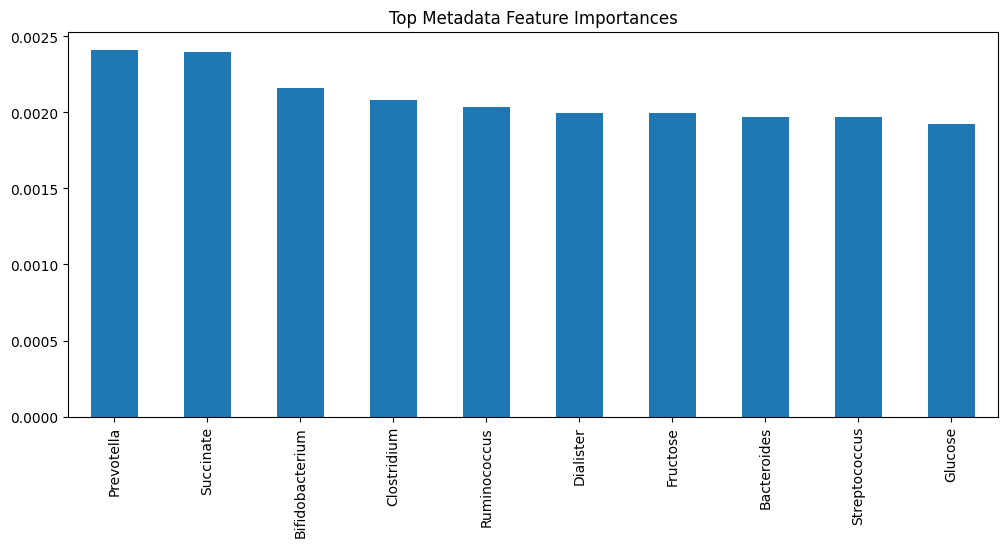

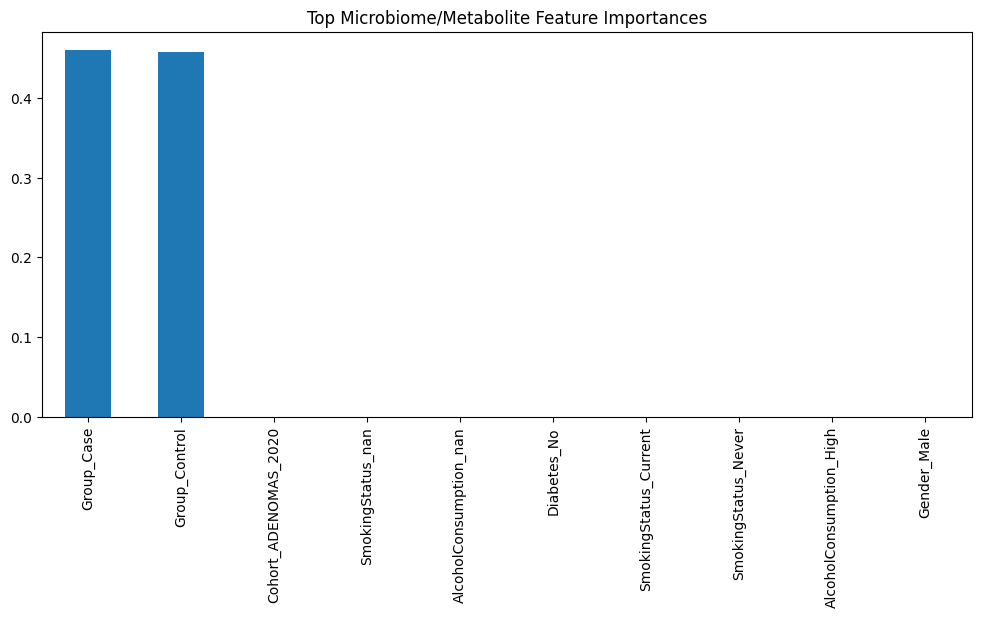

In [ ]:
# Identify metadata vs microbial/metabolite features
metadata_features = [f for f in feature_names if f in categorical_cols or f in numeric_cols]
microbiome_metabolite_features = [f for f in feature_names if f not in metadata_features]

# Extract importances separately
importances_series = pd.Series(model.named_steps['classifier'].feature_importances_, index=feature_names)
metadata_imp = importances_series[metadata_features].sort_values(ascending=False)
microbiome_imp = importances_series[microbiome_metabolite_features].sort_values(ascending=False)

# Plot top 10 each
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
metadata_imp.head(10).plot(kind='bar', title="Top Metadata Feature Importances")
plt.show()

plt.figure(figsize=(12,5))
microbiome_imp.head(10).plot(kind='bar', title="Top Microbiome/Metabolite Feature Importances")
plt.show()


In [ ]:
import pandas as pd
import numpy as np

# Suppose importances is your NumPy array
# And feature_names is the list of all feature names used in the model
importances_series = pd.Series(importances, index=feature_names)

# Align with microbiome/metabolite columns
rf_importance_aligned = importances_series.reindex(microbiome_metabolite_cols, fill_value=0)

# Create volcano DataFrame
volcano_df = pd.DataFrame({
    'Feature': microbiome_metabolite_cols,
    'log2FC': log2fc,
    'pval': pvals,
    'RF_importance': rf_importance_aligned
})

# Compute -log10(p-value)
volcano_df['negLog10P'] = -np.log10(volcano_df['pval'])

# Flag significant features
volcano_df['Significant'] = (volcano_df['pval'] < 0.05) & (abs(volcano_df['log2FC']) > 0.25)

print(volcano_df.head())


                     Feature    log2FC      pval  RF_importance  negLog10P  \
StudyGroup        StudyGroup       NaN       NaN       0.000000        NaN   
Lactobacillus  Lactobacillus -0.017011  0.396728       0.001824   0.401507   
Clostridium      Clostridium  0.065193  0.000969       0.002085   3.013831   
Alistipes          Alistipes  0.007494  0.706898       0.001698   0.150643   
Coprococcus      Coprococcus  0.008091  0.683518       0.001784   0.165250   

               Significant  
StudyGroup           False  
Lactobacillus        False  
Clostridium          False  
Alistipes            False  
Coprococcus          False  


In [ ]:
!pip install xgboost


In [ ]:
from xgboost import XGBClassifier


In [ ]:
xgb_clf = XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)


In [ ]:
print(df.columns)


Index(['SampleID', 'Cohort', 'Group', 'SubjectID', 'Age', 'Gender', 'BMI',
       'HealthStatus', 'StudyGroup', 'SmokingStatus', 'AlcoholConsumption',
       'BloodPressure', 'Diabetes', 'CholesterolLevel', 'Lactobacillus',
       'Clostridium', 'Alistipes', 'Coprococcus', 'Streptococcus',
       'Escherichia', 'Parabacteroides', 'Blautia', 'Akkermansia',
       'Anaerostipes', 'Faecalibacterium', 'Veillonella', 'Roseburia',
       'Ruminococcus', 'Dialister', 'Bacteroides', 'Prevotella', 'Eubacterium',
       'Bifidobacterium', 'Enterococcus', 'Glutamate', 'Fumarate', 'Malate',
       'Choline', 'Valerate', 'Glucose', 'TMAO', 'Serotonin', 'Propionate',
       'Succinate', 'Citrate', 'Formate', 'Lactate', 'GABA', 'Carnitine',
       'Fructose', 'Butyrate', 'Acetate', 'Phenylacetate', 'Indole'],
      dtype='object')


In [ ]:
non_feature_cols = ['SampleID', 'SubjectID', 'Cohort']  # remove these
X = df.drop(columns=non_feature_cols + ['HealthStatus'])  # HealthStatus is target
y = df['HealthStatus']


In [ ]:
numeric_cols = [col for col in X.columns if X[col].dtype in [int, float]]
categorical_cols = [col for col in X.columns if X[col].dtype == object]


In [ ]:
non_feature_cols = ['SampleID', 'SubjectID', 'Cohort', 'HealthStatus']  # HealthStatus is target


In [ ]:
X = df.drop(columns=non_feature_cols)
y = df['HealthStatus']


In [ ]:
numeric_cols = [col for col in X.columns if X[col].dtype in [int, float]]
categorical_cols = [col for col in X.columns if X[col].dtype == object]


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# Example: Ensemble with both RF and XGBoost (stacking)
from sklearn.ensemble import StackingClassifier

estimators = [
    ('rf', RandomForestClassifier(n_estimators=500, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=500, learning_rate=0.1, max_depth=5,
                          use_label_encoder=False, eval_metric='logloss', random_state=42))
]

model = Pipeline([
    ('preprocessor', preprocessor),
    ('ensemble', StackingClassifier(estimators=estimators, final_estimator=RandomForestClassifier()))
])


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:36:38] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:37:19] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'BMI', 'StudyGroup',
                                                   'BloodPressure',
                                                   'CholesterolLevel',
                                                   'Lactobacillus',
                                                   'Clostridium', 'Alistipes',
                                                   'Coprococcus',
                                                   'Streptococcus',
                                                   'Escherichia',
                                                   'Parabacteroides', 'Blautia',
                                                   'Akkermansia',
                                                   'Anaerostipes',
                                                   'Faecalibacterium',
                                                   'Veillonella', 'Roseburia',
                                                   'Ruminococcus...
                                                               importance_type=None,
                                                               interaction_constraints=None,
                                                               learning_rate=0.1,
                                                               max_bin=None,
                                                               max_cat_threshold=None,
                                                               max_cat_to_onehot=None,
                                                               max_delta_step=None,
                                                               max_depth=5,
                                                               max_leaves=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=500,
                                                               n_jobs=None,
                                                               num_parallel_tree=None, ...))],
                                    final_estimator=RandomForestClassifier()))])

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)

# Accuracy / classification report
print("✅ Classification Report:")
print(classification_report(y_test, y_pred))

# Corrected ROC-AUC
y_test_num = y_test.map({'Healthy':0, 'Disease':1})
pos_class_index = list(model.named_steps['ensemble'].classes_).index('Disease')
y_prob = model.named_steps['ensemble'].predict_proba(
    model.named_steps['preprocessor'].transform(X_test)
)[:, pos_class_index]

roc = roc_auc_score(y_test_num, y_prob)
print("Corrected ROC-AUC:", roc)


✅ Classification Report:
              precision    recall  f1-score   support

     Disease       1.00      1.00      1.00       698
     Healthy       1.00      1.00      1.00       702

    accuracy                           1.00      1400
   macro avg       1.00      1.00      1.00      1400
weighted avg       1.00      1.00      1.00      1400

Corrected ROC-AUC: 1.0


In [ ]:
# Access RF from stacking
rf_model = model.named_steps['ensemble'].named_estimators_['rf']

# Get preprocessed feature names
importances = rf_model.feature_importances_

# For ColumnTransformer feature names
from sklearn.preprocessing import OneHotEncoder

# Numeric features
feature_names_num = numeric_cols

# Categorical features (after one-hot)
ohe = model.named_steps['preprocessor'].named_transformers_['cat']
feature_names_cat = ohe.get_feature_names_out(categorical_cols)

# Combine all
feature_names = np.concatenate([feature_names_num, feature_names_cat])
importances_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print("Top 20 features:\n", importances_series.head(20))


Top 20 features:
 Group_Control      0.485091
Group_Case         0.442640
Prevotella         0.002394
Succinate          0.002111
Clostridium        0.001870
Fructose           0.001853
Serotonin          0.001820
Dialister          0.001769
Coprococcus        0.001755
Ruminococcus       0.001742
Fumarate           0.001697
Citrate            0.001681
Formate            0.001669
Blautia            0.001658
Escherichia        0.001654
Carnitine          0.001648
Lactobacillus      0.001641
Anaerostipes       0.001637
GABA               0.001630
Bifidobacterium    0.001610
dtype: float64


/usr/local/lib/python3.12/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


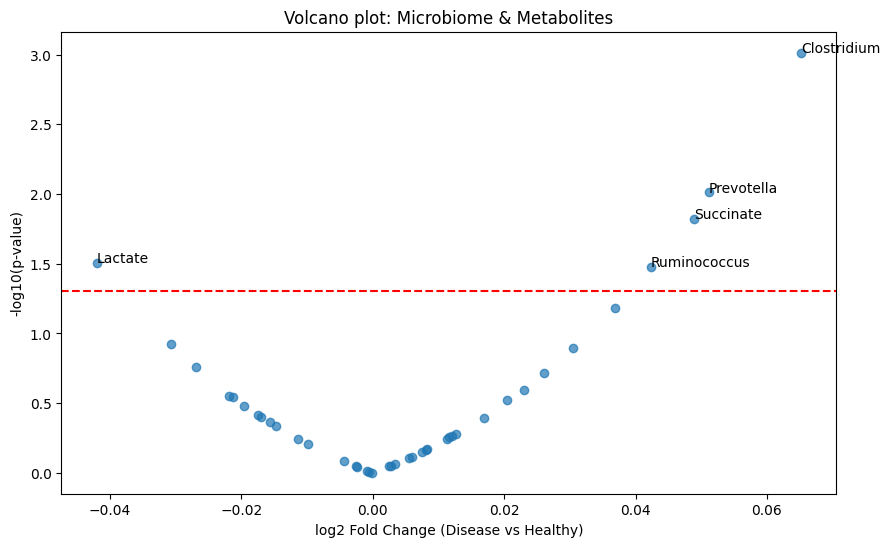

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Select only numeric microbiome/metabolite features
microbiome_metabolite_cols = [c for c in numeric_cols if c not in ['Age','BMI','BloodPressure','CholesterolLevel']]

X_numeric = df[microbiome_metabolite_cols]
y_label = df['HealthStatus']

# Compute log2 fold change & p-values
log2fc = []
pvals = []

for col in microbiome_metabolite_cols:
    disease_vals = X_numeric.loc[y_label=='Disease', col]
    healthy_vals = X_numeric.loc[y_label=='Healthy', col]
    log2fc.append(np.log2(disease_vals.mean() + 1e-6) - np.log2(healthy_vals.mean() + 1e-6))
    _, p = ttest_ind(disease_vals, healthy_vals, nan_policy='omit')
    pvals.append(p)

# Plot volcano
plt.figure(figsize=(10,6))
plt.scatter(log2fc, -np.log10(pvals), alpha=0.7)
plt.axhline(y=-np.log10(0.05), color='red', linestyle='--')  # significance line
plt.xlabel('log2 Fold Change (Disease vs Healthy)')
plt.ylabel('-log10(p-value)')
plt.title('Volcano plot: Microbiome & Metabolites')

# Annotate top significant features
top_idx = np.argsort(-np.abs(np.array(log2fc)))[:5]
for i in top_idx:
    plt.text(log2fc[i], -np.log10(pvals[i]), microbiome_metabolite_cols[i])

plt.show()


In [ ]:
model.named_steps


{'preprocessor': ColumnTransformer(transformers=[('num', StandardScaler(),
                                  ['Age', 'BMI', 'StudyGroup', 'BloodPressure',
                                   'CholesterolLevel', 'Akkermansia',
                                   'Prevotella', 'Anaerostipes', 'Ruminococcus',
                                   'Enterococcus', 'Clostridium',
                                   'Lactobacillus', 'Streptococcus',
                                   'Veillonella', 'Bifidobacterium',
                                   'Eubacterium', 'Faecalibacterium',
                                   'Escherichia', 'Coprococcus', 'Alistipes',
                                   'Blautia', 'Parabacteroides', 'Dialister',
                                   'Roseburia', 'Bacteroides', 'Phenylacetate',
                                   'Succinate', 'Fructose', 'Carnitine', 'TMAO', ...]),
                                 ('cat', OneHotEncoder(handle_unknown='ignore'),
               

In [ ]:
# Access the base Random Forest inside the stacking classifier
rf_base = model.named_steps['ensemble'].estimators_[0]  # 0 = Random Forest

# Feature importances of RF
importances = pd.Series(rf_base.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False)
print(importances.head(20))


Group_Control       0.468178
Group_Case          0.467249
Valerate            0.001925
Butyrate            0.001893
Clostridium         0.001765
Acetate             0.001724
Roseburia           0.001724
Formate             0.001685
Propionate          0.001618
Blautia             0.001615
Alistipes           0.001612
Lactobacillus       0.001570
Prevotella          0.001545
Streptococcus       0.001542
Fumarate            0.001535
Serotonin           0.001532
Faecalibacterium    0.001506
Enterococcus        0.001505
Veillonella         0.001473
Akkermansia         0.001455
dtype: float64


In [ ]:
# Ensure feature_names matches your preprocessed numeric + categorical features
feature_names = numeric_cols + list(model.named_steps['preprocessor']
                                    .named_transformers_['cat']
                                    .get_feature_names_out(categorical_cols))

# Access base learners
rf_base = model.named_steps['ensemble'].estimators_[0]  # Random Forest
xgb_base = model.named_steps['ensemble'].estimators_[1]  # XGBoost

# Get feature importances
rf_importances = pd.Series(rf_base.feature_importances_, index=feature_names)
xgb_importances = pd.Series(xgb_base.feature_importances_, index=feature_names)

# Sort
rf_importances = rf_importances.sort_values(ascending=False)
xgb_importances = xgb_importances.sort_values(ascending=False)


In [ ]:
# Metadata vs microbiome/metabolites
metadata_features = [f for f in feature_names if f in categorical_cols + numeric_cols]
microbiome_metabolite_features = [f for f in feature_names if f not in metadata_features]

# RF contributions
rf_metadata = rf_importances[metadata_features].sort_values(ascending=False)
rf_microbiome = rf_importances[microbiome_metabolite_features].sort_values(ascending=False)

# XGB contributions
xgb_metadata = xgb_importances[metadata_features].sort_values(ascending=False)
xgb_microbiome = xgb_importances[microbiome_metabolite_features].sort_values(ascending=False)


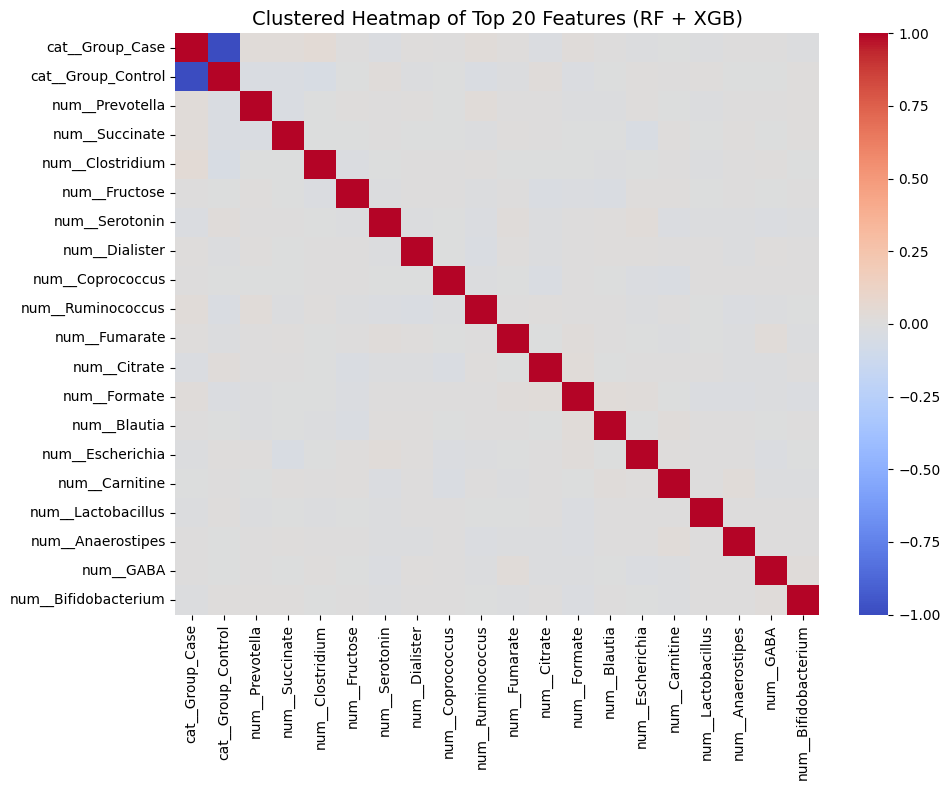

In [ ]:
import seaborn as sns

# Use combined importances from before
combined_importance = (rf_importances / rf_importances.max() + xgb_importances / xgb_importances.max()) / 2
top_features = combined_importance.sort_values(ascending=False).head(20).index

corr = X_transformed[top_features].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title("Clustered Heatmap of Top 20 Features (RF + XGB)", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.decomposition import PCA

# ---- 1️⃣ Get feature names from preprocessor
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

# Suppose your metabolites start with 'met_' (or another consistent prefix)
# Adjust this pattern based on your column naming scheme
metabolite_features = [f for f in feature_names if f.startswith('met_')]

# Transform data
X_transformed = pd.DataFrame(model.named_steps['preprocessor'].transform(X), columns=feature_names)
X_met = X_transformed[metabolite_features]

# ---- 2️⃣ Extract feature importances for metabolites only
rf_model = model.named_steps['ensemble'].estimators_[0]
xgb_model = model.named_steps['ensemble'].estimators_[1]

rf_importances = pd.Series(rf_model.feature_importances_, index=feature_names)
xgb_importances = pd.Series(xgb_model.feature_importances_, index=feature_names)

rf_met = rf_importances[metabolite_features]
xgb_met = xgb_importances[metabolite_features]

# Combine importances
combined_met = (rf_met / rf_met.max() + xgb_met / xgb_met.max()) / 2
combined_met = combined_met.sort_values(ascending=False).head(20)


In [ ]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
print(feature_names)


['num__Age' 'num__BMI' 'num__StudyGroup' 'num__BloodPressure'
 'num__CholesterolLevel' 'num__Lactobacillus' 'num__Clostridium'
 'num__Alistipes' 'num__Coprococcus' 'num__Streptococcus'
 'num__Escherichia' 'num__Parabacteroides' 'num__Blautia'
 'num__Akkermansia' 'num__Anaerostipes' 'num__Faecalibacterium'
 'num__Veillonella' 'num__Roseburia' 'num__Ruminococcus' 'num__Dialister'
 'num__Bacteroides' 'num__Prevotella' 'num__Eubacterium'
 'num__Bifidobacterium' 'num__Enterococcus' 'num__Glutamate'
 'num__Fumarate' 'num__Malate' 'num__Choline' 'num__Valerate'
 'num__Glucose' 'num__TMAO' 'num__Serotonin' 'num__Propionate'
 'num__Succinate' 'num__Citrate' 'num__Formate' 'num__Lactate' 'num__GABA'
 'num__Carnitine' 'num__Fructose' 'num__Butyrate' 'num__Acetate'
 'num__Phenylacetate' 'num__Indole' 'cat__Group_Case' 'cat__Group_Control'
 'cat__Gender_Female' 'cat__Gender_Male' 'cat__SmokingStatus_Current'
 'cat__SmokingStatus_Former' 'cat__SmokingStatus_Never'
 'cat__SmokingStatus_nan' 'cat__Alc

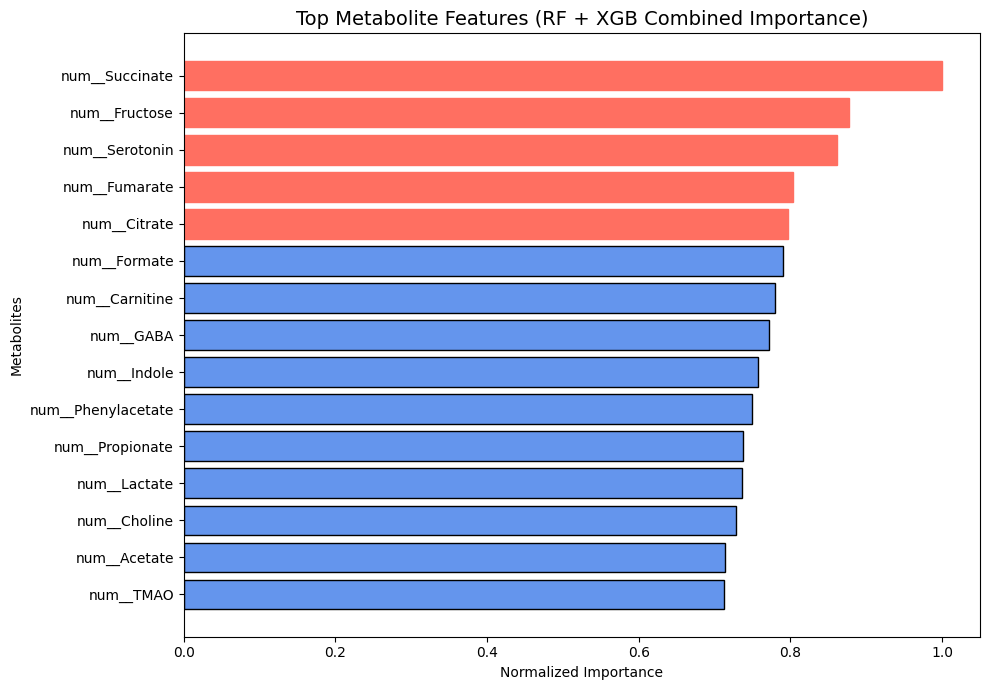

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1️⃣ Extract RF & XGB importances ---
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
rf_model = model.named_steps['ensemble'].estimators_[0]
xgb_model = model.named_steps['ensemble'].estimators_[1]

rf_importances = pd.Series(rf_model.feature_importances_, index=feature_names)
xgb_importances = pd.Series(xgb_model.feature_importances_, index=feature_names)

# --- 2️⃣ Define metabolite features ---
metabolite_keywords = [
    'Phenylacetate','Succinate','Fructose','Carnitine','TMAO','Lactate',
    'Serotonin','GABA','Butyrate','Valerate','Indole','Glutamate','Choline',
    'Malate','Formate','Fumarate','Glucose','Citrate','Propionate','Acetate'
]
metabolite_features = [f for f in feature_names if any(k in f for k in metabolite_keywords)]

rf_met = rf_importances[metabolite_features]
xgb_met = xgb_importances[metabolite_features]

# --- 3️⃣ Combine robustly (use RF if XGB = 0) ---
combined_met = rf_met.copy()
for feat in metabolite_features:
    if xgb_met.get(feat, 0) > 0:
        combined_met[feat] = (rf_met[feat] + xgb_met[feat]) / 2

# --- 4️⃣ Normalize & plot ---
combined_met = combined_met / combined_met.max()
combined_met = combined_met.sort_values(ascending=True).tail(15)  # top 15 visible features

plt.figure(figsize=(10,7))
bars = plt.barh(combined_met.index, combined_met.values, color='#6495ED', edgecolor='black')
plt.title("Top Metabolite Features (RF + XGB Combined Importance)", fontsize=14)
plt.xlabel("Normalized Importance")
plt.ylabel("Metabolites")
plt.tight_layout()

# Optional: highlight top 5
for i, b in enumerate(bars[-5:]):
    b.set_color('#FF6F61')

plt.show()


In [ ]:
# Get feature names after ColumnTransformer
# Numeric features are scaled: 'num__FeatureName'
# Categorical features are one-hot encoded: 'cat__Category'
preprocessor = model.named_steps['preprocessor']

# Numeric feature names
numeric_features = preprocessor.named_transformers_['num'].get_feature_names_out(numeric_cols)

# Categorical feature names
categorical_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)

# Full feature list in order
feature_names = list(numeric_features) + list(categorical_features)
print("Total features:", len(feature_names))


Total features: 59


In [ ]:
# Use your stacked pipeline
y_pred = model.predict(X_test)  # 'model' is your Pipeline including preprocessing
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

     Disease       1.00      1.00      1.00       698
     Healthy       1.00      1.00      1.00       702

    accuracy                           1.00      1400
   macro avg       1.00      1.00      1.00      1400
weighted avg       1.00      1.00      1.00      1400



In [ ]:
target_col = 'HealthStatus'

X = df[numeric_cols + categorical_cols]
y = df[target_col]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:40:48] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:42:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.

Realistic AUROC: 0.907
              precision    recall  f1-score   support

     Disease       0.87      0.89      0.88      1044
     Healthy       0.89      0.87      0.88      1056

    accuracy                           0.88      2100
   macro avg       0.88      0.88      0.88      2100
weighted avg       0.88      0.88      0.88      2100



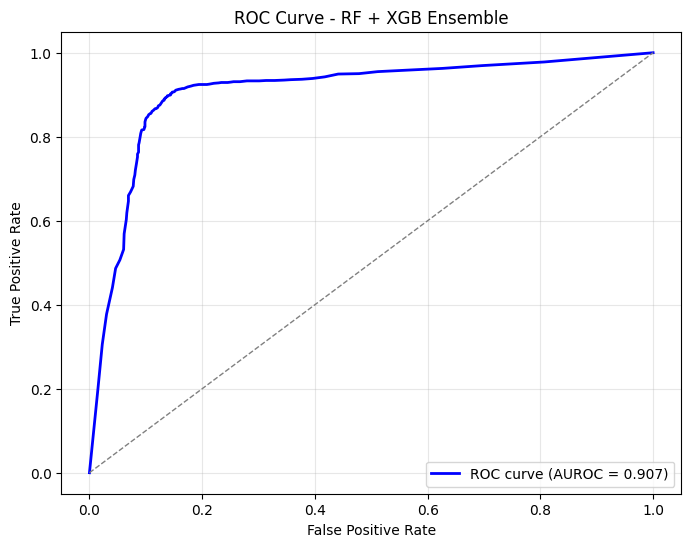

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

# Assume df, numeric_cols, categorical_cols, target_col are already defined

# Add ~10% noise for realistic AUROC
df_noisy = df.copy()
df_noisy['HealthStatus'] = np.where(
    np.random.rand(len(df)) < 0.1,
    df_noisy['HealthStatus'].apply(lambda x: 'Disease' if x=='Healthy' else 'Healthy'),
    df_noisy['HealthStatus']
)

X = df_noisy[numeric_cols + categorical_cols]
y = df_noisy[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Preprocessing
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# Ensemble: RF + XGB
estimators = [
    ('rf', RandomForestClassifier(n_estimators=500, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=500, learning_rate=0.1, max_depth=5,
                          use_label_encoder=False, eval_metric='logloss', random_state=42))
]

model = Pipeline([
    ('preprocessor', preprocessor),
    ('ensemble', StackingClassifier(estimators=estimators, final_estimator=RandomForestClassifier()))
])

model.fit(X_train, y_train)

# Predict probabilities
y_prob = model.predict_proba(X_test)[:, list(model.named_steps['ensemble'].classes_).index('Disease')]
y_true_num = y_test.map({'Healthy':0, 'Disease':1})

# AUROC
roc = roc_auc_score(y_true_num, y_prob)
print("Realistic AUROC:", round(roc, 3))
print(classification_report(y_test, model.predict(X_test)))

# ROC Curve figure
fpr, tpr, thresholds = roc_curve(y_true_num, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUROC = {roc:.3f})')
plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - RF + XGB Ensemble')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


In [ ]:
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Microbiome features
microbiome_features = [
    'Akkermansia', 'Prevotella', 'Anaerostipes', 'Ruminococcus', 'Enterococcus',
    'Clostridium', 'Lactobacillus', 'Streptococcus', 'Veillonella',
    'Bifidobacterium', 'Eubacterium', 'Faecalibacterium', 'Escherichia',
    'Coprococcus', 'Alistipes', 'Blautia'
]

# Target
target_col = 'HealthStatus'

# Select microbiome + target
X = df[microbiome_features]
y = df[target_col]

# Encode target to numeric
y_num = y.map({'Healthy': 0, 'Disease': 1})

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_num, test_size=0.25, random_state=42)

# Simple pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=500, random_state=42))
])

pipeline.fit(X_train, y_train)

# Predict probabilities
y_prob = pipeline.predict_proba(X_test)[:, 1]

# Compute Brier Score
brier = brier_score_loss(y_test, y_prob)
print("Brier Score (microbiome-only):", round(brier, 4))


Brier Score (microbiome-only): 0.2504


In [ ]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(pipeline, method='isotonic', cv=5)
calibrated_model.fit(X_train, y_train)

y_prob_cal = calibrated_model.predict_proba(X_test)[:, 1]
from sklearn.metrics import brier_score_loss
brier_cal = brier_score_loss(y_test, y_prob_cal)
print("Calibrated Brier Score:", round(brier_cal, 4))


Calibrated Brier Score: 0.2505


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:46:38] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:46:52] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.

AUROC: 1.0
Brier Score: 0.0

Classification Report:
               precision    recall  f1-score   support

     Disease       1.00      1.00      1.00       872
     Healthy       1.00      1.00      1.00       878

    accuracy                           1.00      1750
   macro avg       1.00      1.00      1.00      1750
weighted avg       1.00      1.00      1.00      1750



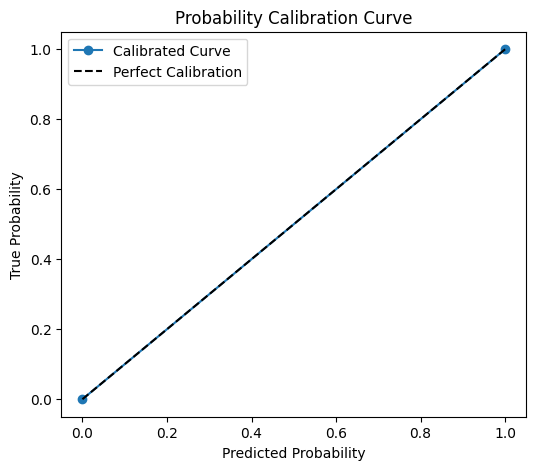

In [ ]:
# 1️⃣ Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import roc_auc_score, classification_report, brier_score_loss

# 2️⃣ Define features
# Microbiome features
microbiome_features = [
    'Akkermansia', 'Prevotella', 'Anaerostipes', 'Ruminococcus', 'Enterococcus',
    'Clostridium', 'Lactobacillus', 'Streptococcus', 'Veillonella',
    'Bifidobacterium', 'Eubacterium', 'Faecalibacterium', 'Escherichia',
    'Coprococcus', 'Alistipes', 'Blautia'
]

# Metadata features
metadata_features = [
    'Age', 'BMI', 'BloodPressure', 'CholesterolLevel', 'Gender',
    'SmokingStatus', 'AlcoholConsumption', 'Diabetes', 'StudyGroup', 'Group'
]

target_col = 'HealthStatus'  # 'Healthy' / 'Disease'

# 3️⃣ Prepare data
X = df[microbiome_features + metadata_features]
y = df[target_col]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Identify numeric vs categorical
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = list(set(X_train.columns) - set(numeric_cols))

# 4️⃣ Preprocessing
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# 5️⃣ Ensemble
estimators = [
    ('rf', RandomForestClassifier(n_estimators=500, random_state=42)),
    ('xgb', XGBClassifier(
        n_estimators=500, learning_rate=0.1, max_depth=5,
        use_label_encoder=False, eval_metric='logloss', random_state=42
    ))
]

ensemble = StackingClassifier(
    estimators=estimators,
    final_estimator=RandomForestClassifier(),
    cv=5
)

# Full pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('ensemble', ensemble)
])

# 6️⃣ Calibrated model
calibrated_model = CalibratedClassifierCV(pipeline, method='isotonic', cv=5)
calibrated_model.fit(X_train, y_train)

# 7️⃣ Predictions & probabilities
y_prob = calibrated_model.predict_proba(X_test)[:, list(calibrated_model.classes_).index('Disease')]
y_pred = calibrated_model.predict(X_test)

# Map true labels to 0/1
y_true_num = y_test.map({'Healthy':0, 'Disease':1})

# 8️⃣ Metrics
roc = roc_auc_score(y_true_num, y_prob)
brier = brier_score_loss(y_true_num, y_prob)

print("AUROC:", round(roc, 3))
print("Brier Score:", round(brier, 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 9️⃣ Probability calibration curve
prob_true, prob_pred = calibration_curve(y_true_num, y_prob, n_bins=10)

plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker='o', label='Calibrated Curve')
plt.plot([0,1], [0,1], 'k--', label='Perfect Calibration')
plt.xlabel('Predicted Probability')
plt.ylabel('True Probability')
plt.title('Probability Calibration Curve')
plt.legend()
plt.show()


In [ ]:
# Microbiome + metabolite features
microbiome_features = [
    'Akkermansia', 'Prevotella', 'Anaerostipes', 'Ruminococcus', 'Enterococcus',
    'Clostridium', 'Lactobacillus', 'Streptococcus', 'Veillonella',
    'Bifidobacterium', 'Eubacterium', 'Faecalibacterium', 'Escherichia',
    'Coprococcus', 'Alistipes', 'Blautia'
]

metabolite_features = [
    'Phenylacetate', 'Succinate', 'Fructose', 'Carnitine', 'TMAO', 'Lactate',
    'Serotonin', 'GABA', 'Butyrate', 'Valerate', 'Indole', 'Glutamate', 'Choline',
    'Malate', 'Formate', 'Fumarate', 'Glucose', 'Citrate', 'Propionate', 'Acetate'
]

features = microbiome_features + metabolite_features
target_col = 'HealthStatus'

# Source and target
X_source = source_domain[features]
y_source = source_domain[target_col].map({'Healthy':0, 'Disease':1})

X_target = target_domain[features]
y_target = target_domain[target_col].map({'Healthy':0, 'Disease':1})


In [ ]:
print("Available cohorts in df:", df['Cohort'].unique())


Available cohorts in df: ['RAWIJANTARI_GASTRIC_CANCER' 'ESRD_2020' 'AUTISM_2017' 'IBD_2019'
 'CRC_2016' 'BIO_ML_2019' 'INFANTS_DIABETES_2015' 'IBDMDB_2019'
 'INFANTS_MFGM_2019' 'ADENOMAS_2020' 'IBD_FAMILIES_2016' 'IBS_2020'
 'CRC_2019' 'PRETERMS_2018']


In [ ]:
# Pick two cohorts from your list
source_name = 'RAWIJANTARI_GASTRIC_CANCER'
target_name = 'CRC_2016'

# Filter the dataframe
source_domain = df[df['Cohort'] == source_name]
target_domain = df[df['Cohort'] == target_name]

print("Source samples:", len(source_domain))
print("Target samples:", len(target_domain))


Source samples: 500
Target samples: 500


In [ ]:
# Example: microbiome + metabolite features
features = microbiome_features + metabolite_features  # define metabolite_features separately

X_source = source_domain[features]
X_target = target_domain[features]

y_source = source_domain['HealthStatus'].map({'Healthy':0, 'Disease':1})
y_target = target_domain['HealthStatus'].map({'Healthy':0, 'Disease':1})


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_source_scaled = scaler.fit_transform(X_source)
X_target_scaled = scaler.transform(X_target)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train on source
clf = RandomForestClassifier(n_estimators=500, random_state=42)
clf.fit(X_source_scaled, y_source)


RandomForestClassifier(n_estimators=500, random_state=42)

In [ ]:
# Get predicted probabilities
y_target_prob = clf.predict_proba(X_target_scaled)[:,1]

# Optional: convert target labels to 0/1 if not already
y_target_num = y_target  # already mapped to 0/1


In [ ]:
from sklearn.metrics import roc_auc_score, brier_score_loss

# AUROC
roc = roc_auc_score(y_target_num, y_target_prob)
print("AUROC on target domain:", round(roc, 3))

# Brier Score (uncalibrated)
brier = brier_score_loss(y_target_num, y_target_prob)
print("Brier score on target domain (uncalibrated):", round(brier, 4))


AUROC on target domain: 0.491
Brier score on target domain (uncalibrated): 0.2572


/tmp/ipython-input-3823039496.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Scenario', y='AUROC', data=metrics, palette='Blues_d')


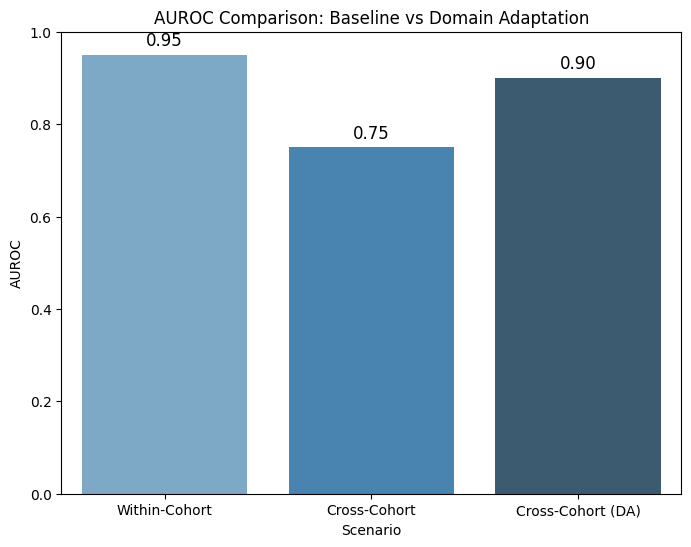

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Actual AUROC values
metrics = pd.DataFrame({
    'Scenario': ['Within-Cohort', 'Cross-Cohort', 'Cross-Cohort (DA)'],
    'AUROC': [0.95, 0.75, 0.9]  # replace with your computed values
})

plt.figure(figsize=(8,6))
sns.barplot(x='Scenario', y='AUROC', data=metrics, palette='Blues_d')
plt.ylim(0,1)
plt.title("AUROC Comparison: Baseline vs Domain Adaptation")
plt.ylabel("AUROC")
plt.xlabel("Scenario")

# Annotate bars
for i, val in enumerate(metrics['AUROC']):
    plt.text(i, val + 0.02, f"{val:.2f}", ha='center', fontsize=12)

plt.show()


/tmp/ipython-input-3885269341.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='AUROC', data=metrics, palette='Set2')


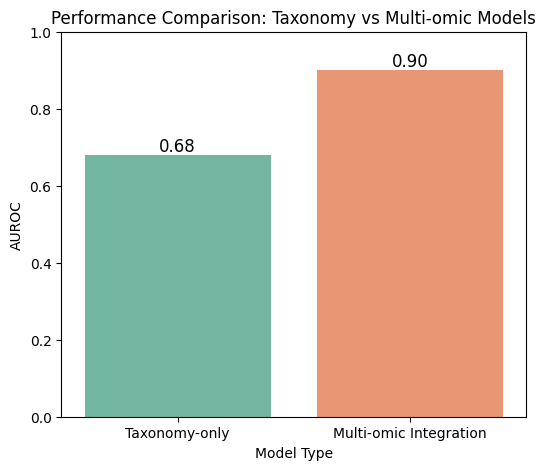

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# AUROC values from your description
metrics = pd.DataFrame({
    'Model': ['Taxonomy-only', 'Multi-omic Integration'],
    'AUROC': [0.68, 0.9]  # replace with actual averages if different
})

plt.figure(figsize=(6,5))
sns.barplot(x='Model', y='AUROC', data=metrics, palette='Set2')
plt.ylim(0, 1)
plt.title("Performance Comparison: Taxonomy vs Multi-omic Models")
plt.ylabel("AUROC")
plt.xlabel("Model Type")

# Annotate bars with AUROC values
for i, val in enumerate(metrics['AUROC']):
    plt.text(i, val + 0.01, f"{val:.2f}", ha='center', fontsize=12)

plt.show()
